# Notebook 2 ? Forward Process and Noise Distributions

This notebook studies the three noise families used in the project and clarifies an important methodological point:

- **Gaussian** is the exact DDPM-style baseline.
- **Uniform** and **Laplace** are kept as **matched-variance direct-corruption surrogates**.
- Matching the variance is useful, but it does **not** make the non-Gaussian shortcut mathematically identical to the Gaussian forward-process derivation.

What this notebook now does:
1. checks that all three noise samplers are standardised,
2. visualises the sampled distributions and the forward corruption process,
3. adds a lightweight diagnostic comparing the closed-form shortcut with an exact iterative accumulation view.


## 1. Setup

This notebook can be run on Colab immediately after Notebook 1. It keeps the same `PROJECT_DIR` and uses the same beta schedule.


In [1]:
!pip install -q torch torchvision matplotlib numpy

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/diffusion_noise_project'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Device: {DEVICE}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Device: cuda


In [3]:
# Paste CONFIG and make_beta_schedule from Notebook 1, then:
CONFIG = {
    'dataset': 'MNIST', 'image_size': 28, 'channels': 1, 'batch_size': 128,
    'T': 1000, 'beta_start': 1e-4, 'beta_end': 0.02, 'schedule': 'linear',
    'num_epochs': 30, 'lr': 2e-4, 'optimizer': 'adamw', 'weight_decay': 1e-4,
    'num_workers': 2, 'model_channels': 64, 'channel_mults': (1, 2, 4),
    'log_every': 100, 'save_every': 5, 'seed': 42,
}

def make_beta_schedule(schedule, T, beta_start, beta_end):
    if schedule == 'linear':
        betas = torch.linspace(beta_start, beta_end, T)
    elif schedule == 'cosine':
        steps = T + 1
        x = torch.linspace(0, T, steps)
        alphas_cumprod = torch.cos(((x / T) + 0.008) / 1.008 * torch.pi / 2) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        betas = betas.clamp(0, 0.999)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]])
    return {
        'betas': betas, 'alphas': alphas,
        'alphas_cumprod': alphas_cumprod,
        'alphas_cumprod_prev': alphas_cumprod_prev,
        'sqrt_alphas_cumprod': alphas_cumprod.sqrt(),
        'sqrt_one_minus_alphas_cumprod': (1 - alphas_cumprod).sqrt(),
    }

schedule = make_beta_schedule(CONFIG['schedule'], CONFIG['T'], CONFIG['beta_start'], CONFIG['beta_end'])

# Base class
class ForwardDiffusion:
    def __init__(self, schedule, device):
        self.device = device
        self.T = len(schedule['betas'])
        for k, v in schedule.items():
            setattr(self, k, v.to(device))
    def sample_noise(self, shape):
        raise NotImplementedError
    def sample_timestep(self, batch_size):
        return torch.randint(0, self.T, (batch_size,), device=self.device).long()
    def q_sample(self, x_0, t):
        eps = self.sample_noise(x_0.shape)
        sqrt_alpha_bar = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_one_minus_alpha_bar = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * eps
        return x_t, eps
    def noise_stats(self, n_samples=100000):
        noise = self.sample_noise((n_samples, 1, 1, 1))
        return {'mean': noise.mean().item(), 'std': noise.std().item()}

print('Base classes loaded.')

Base classes loaded.


## 2. Three Noise Distributions

All three samplers are standardised to **mean = 0** and **variance = 1**.
That makes the comparison fair in terms of overall noise power.

Interpretation reminder:
- **Gaussian:** exact DDPM-style forward noise.
- **Uniform / Laplace:** same variance target, but still treated as surrogate direct-corruption experiments.

| Distribution | Raw parameterisation | Standardised form | Role in this project |
|---|---|---|---|
| Gaussian | N(0, 1) | Already standard | Exact baseline |
| Uniform | U(-a, a) | a = sqrt(3) so var = 1 | Surrogate comparison |
| Laplace | Lap(0, b) | b = 1/sqrt(2) so var = 1 | Surrogate comparison |


In [4]:
class GaussianDiffusion(ForwardDiffusion):
    """
    Exact DDPM-style baseline with Gaussian noise.
    """
    name = 'gaussian'

    def sample_noise(self, shape):
        return torch.randn(shape, device=self.device)


class UniformDiffusion(ForwardDiffusion):
    """
    Matched-variance surrogate with eps ~ U(-sqrt(3), sqrt(3)).
    """
    name = 'uniform'
    _a = 3 ** 0.5

    def sample_noise(self, shape):
        return torch.empty(shape, device=self.device).uniform_(-self._a, self._a)


class LaplaceDiffusion(ForwardDiffusion):
    """
    Matched-variance surrogate with eps ~ Laplace(0, 1/sqrt(2)).

    The clamp avoids log(0) in the inverse-CDF sampler and prevents the
    non-finite values that can destabilise training.
    """
    name = 'laplace'
    _b = 2 ** -0.5
    _eps = 1e-6

    def sample_noise(self, shape):
        u = torch.empty(shape, device=self.device).uniform_(-0.5 + self._eps, 0.5 - self._eps)
        safe_term = (1 - 2 * u.abs()).clamp_min(1e-12)
        return -self._b * u.sign() * torch.log(safe_term)


print('All three diffusion classes defined.')


All three diffusion classes defined.


## 3. Verify Standardisation

Besides mean and standard deviation, we also print the excess kurtosis.
That helps distinguish the heavier Laplace tails from the flatter Uniform shape.


In [5]:
diffusions = {
    'Gaussian': GaussianDiffusion(schedule, DEVICE),
    'Uniform':  UniformDiffusion(schedule, DEVICE),
    'Laplace':  LaplaceDiffusion(schedule, DEVICE),
}

print(f"{'Distribution':<12} {'Mean':>10} {'Std':>10} {'Ex.Kurt.':>10} {'Min':>10} {'Max':>10}")
print('-' * 72)
for name, diff in diffusions.items():
    noise = diff.sample_noise((500000, 1, 1, 1)).reshape(-1)
    centred = (noise - noise.mean()) / noise.std(unbiased=False)
    excess_kurtosis = centred.pow(4).mean().item() - 3.0
    print(
        f"{name:<12} {noise.mean().item():>10.4f} {noise.std().item():>10.4f} "
        f"{excess_kurtosis:>10.4f} {noise.min().item():>10.4f} {noise.max().item():>10.4f}"
    )


Distribution       Mean        Std   Ex.Kurt.        Min        Max
------------------------------------------------------------------------
Gaussian         0.0015     0.9987    -0.0088    -4.4288     4.7518
Uniform         -0.0003     1.0002    -1.2016    -1.7320     1.7320
Laplace         -0.0017     0.9965     3.0216    -8.8919     8.7390


## 4. Distribution Shape Comparison

The histogram matches the theoretical PDF in all three cases. The important difference is not the mean or variance, but the tail behaviour.


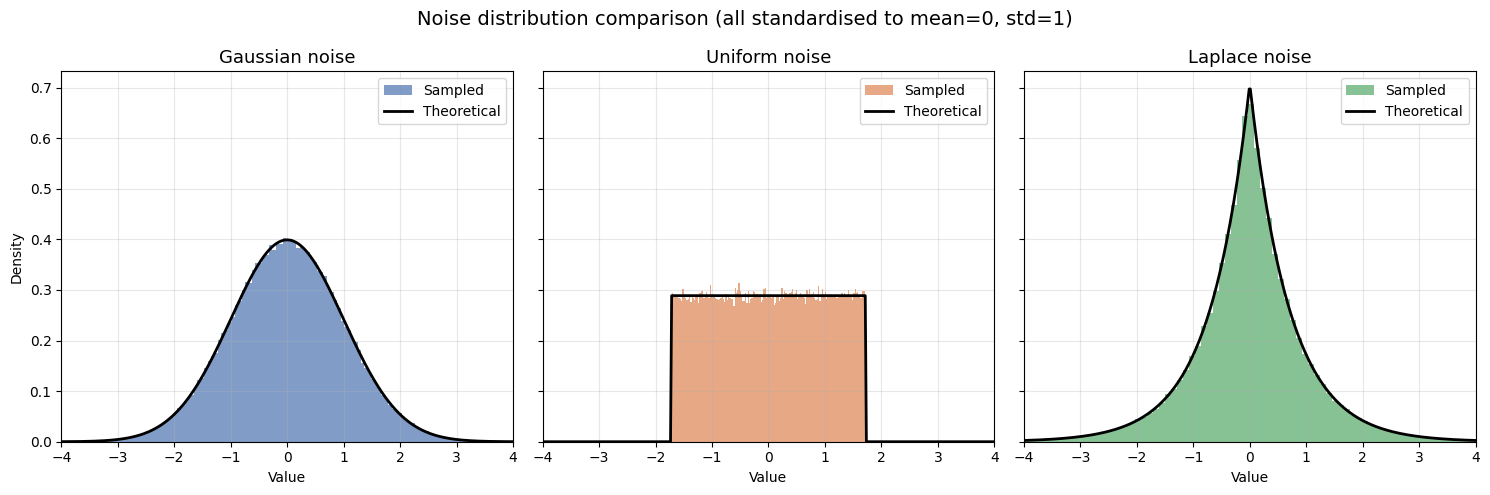

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = {'Gaussian': '#4C72B0', 'Uniform': '#DD8452', 'Laplace': '#55A868'}
x_range = np.linspace(-4, 4, 400)

for ax, (name, diff) in zip(axes, diffusions.items()):
    noise = diff.sample_noise((200000, 1, 1, 1)).cpu().numpy().flatten()
    ax.hist(noise, bins=150, density=True, alpha=0.7, color=colors[name], label='Sampled')

    # Theoretical PDFs
    if name == 'Gaussian':
        pdf = np.exp(-x_range**2 / 2) / np.sqrt(2 * np.pi)
        ax.plot(x_range, pdf, 'k-', lw=2, label='Theoretical')
    elif name == 'Uniform':
        a = 3**0.5
        pdf = np.where(np.abs(x_range) <= a, 1 / (2 * a), 0)
        ax.plot(x_range, pdf, 'k-', lw=2, label='Theoretical')
    elif name == 'Laplace':
        b = 2**-0.5
        pdf = np.exp(-np.abs(x_range) / b) / (2 * b)
        ax.plot(x_range, pdf, 'k-', lw=2, label='Theoretical')

    ax.set_title(f'{name} noise', fontsize=13)
    ax.set_xlabel('Value')
    ax.set_xlim(-4, 4)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Density')
plt.suptitle('Noise distribution comparison (all standardised to mean=0, std=1)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'noise_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Forward Process Visualisation

These images use the same closed-form shortcut in all three rows.
For the **Gaussian** row this is the exact DDPM interpretation.
For the **Uniform** and **Laplace** rows, it is a practical direct-corruption surrogate with matched variance.


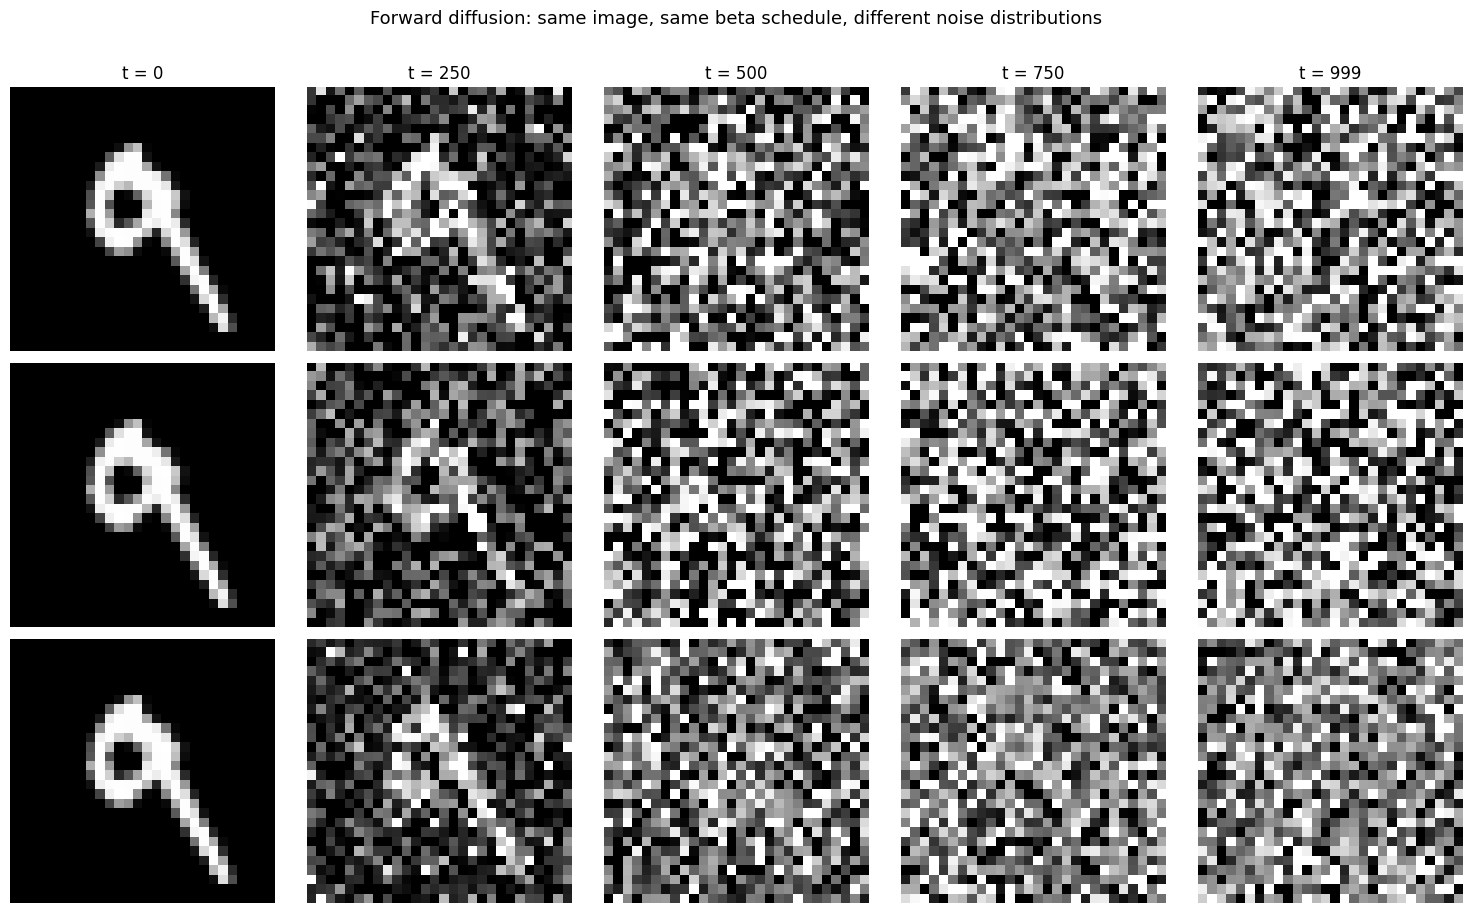

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_dataset = torchvision.datasets.MNIST(
    root='/content/data', train=False, download=True, transform=transform
)

# Pick a clean sample
torch.manual_seed(CONFIG['seed'])
x_0 = test_dataset[7][0].unsqueeze(0).to(DEVICE)  # shape (1, 1, 28, 28)

timesteps = [0, 250, 500, 750, 999]
dist_names = list(diffusions.keys())

fig, axes = plt.subplots(len(dist_names), len(timesteps), figsize=(15, 9))

for row, (dist_name, diff) in enumerate(diffusions.items()):
    for col, t_val in enumerate(timesteps):
        if t_val == 0:
            img = x_0
        else:
            t_tensor = torch.tensor([t_val], device=DEVICE)
            img, _ = diff.q_sample(x_0, t_tensor)

        # Unnormalise
        img_display = (img.squeeze().cpu() * 0.5 + 0.5).clamp(0, 1).numpy()
        axes[row, col].imshow(img_display, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

        if row == 0:
            axes[row, col].set_title(f't = {t_val}', fontsize=12)
        if col == 0:
            axes[row, col].set_ylabel(dist_name, fontsize=12, rotation=90, labelpad=10)

plt.suptitle('Forward diffusion: same image, same beta schedule, different noise distributions',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'forward_diffusion_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Noise Power as a Function of t

This confirms that all three setups inject nearly the same variance at the image level.
That is useful, but it does **not** prove that the full forward-process law is identical across distributions.


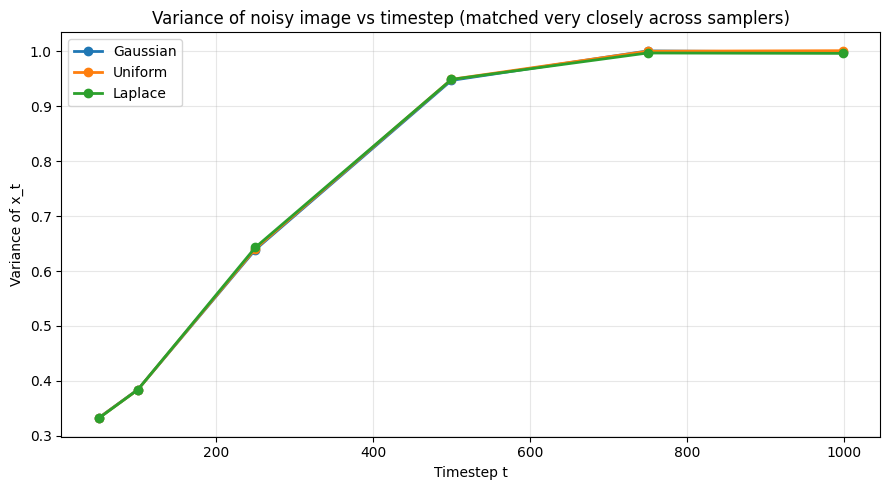

In [8]:
# Sample a clean image and compute the variance of x_t over many noise samples
t_values = [50, 100, 250, 500, 750, 999]
n_repeats = 500

results = {name: [] for name in diffusions}

for t_val in t_values:
    t_tensor = torch.tensor([t_val], device=DEVICE)
    for name, diff in diffusions.items():
        variances = []
        for _ in range(n_repeats):
            x_t, _ = diff.q_sample(x_0, t_tensor)
            variances.append(x_t.var().item())
        results[name].append(np.mean(variances))

fig, ax = plt.subplots(figsize=(9, 5))
for name, vals in results.items():
    ax.plot(t_values, vals, marker='o', label=name, linewidth=2)

ax.set_xlabel('Timestep t')
ax.set_ylabel('Variance of x_t')
ax.set_title('Variance of noisy image vs timestep (matched very closely across samplers)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'noise_variance_vs_t.png'), dpi=150)
plt.show()


## 7. Methodology Diagnostic ? Closed-form vs Iterative Accumulation

The Gaussian shortcut
`x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps`
is exact because sums of Gaussian variables stay Gaussian.

For Uniform and Laplace, the direct shortcut and the exact iterative chain do **not** have the same higher-order shape. The comparison below tracks the **excess kurtosis** of the noise-only process.


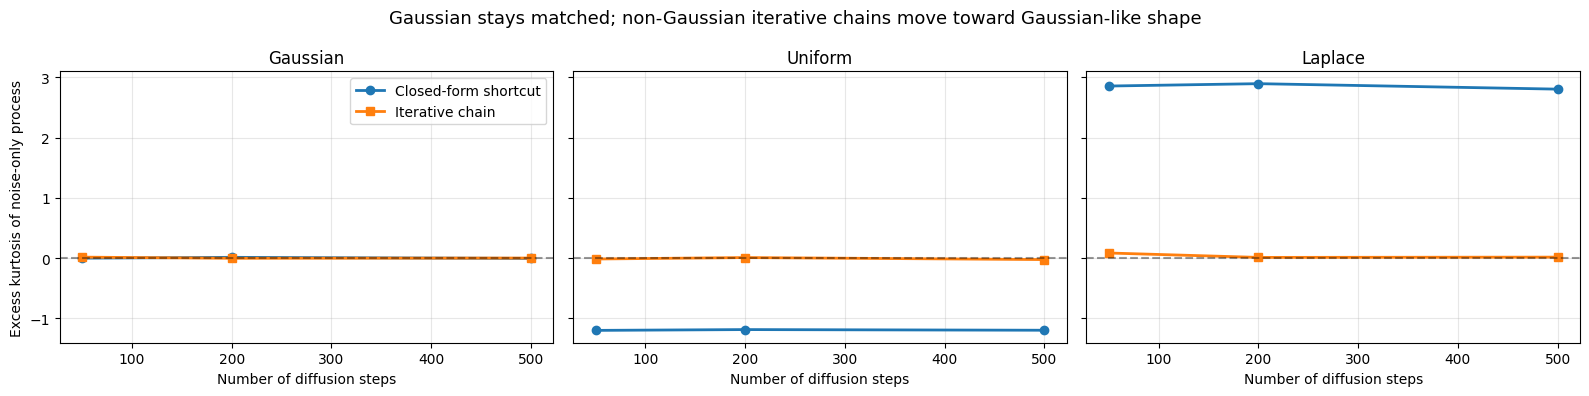

Excess kurtosis diagnostic:

Gaussian
  t= 50 | shortcut= -0.002 | iterative=  0.015
  t=200 | shortcut=  0.011 | iterative= -0.004
  t=500 | shortcut= -0.007 | iterative= -0.000

Uniform
  t= 50 | shortcut= -1.202 | iterative= -0.016
  t=200 | shortcut= -1.188 | iterative=  0.008
  t=500 | shortcut= -1.199 | iterative= -0.026

Laplace
  t= 50 | shortcut=  2.856 | iterative=  0.083
  t=200 | shortcut=  2.895 | iterative=  0.010
  t=500 | shortcut=  2.804 | iterative=  0.015


In [9]:
probe_timesteps = [49, 199, 499]
n_samples = 40000


def excess_kurtosis(x):
    x = x.reshape(-1)
    x = x[torch.isfinite(x)]
    centred = (x - x.mean()) / x.std(unbiased=False)
    return centred.pow(4).mean().item() - 3.0


def direct_noise_only(diff, t_val, n_samples):
    scale = diff.sqrt_one_minus_alphas_cumprod[t_val]
    eps = diff.sample_noise((n_samples,))
    return scale * eps


def iterative_noise_snapshots(diff, probe_timesteps, n_samples):
    snapshots = {}
    max_t = max(probe_timesteps)
    x = torch.zeros(n_samples, device=DEVICE)
    probe_set = set(probe_timesteps)

    for step in range(max_t + 1):
        eps = diff.sample_noise((n_samples,))
        x = diff.alphas[step].sqrt() * x + diff.betas[step].sqrt() * eps
        if step in probe_set:
            snapshots[step] = x.clone()

    return snapshots


summary = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (name, diff) in zip(axes, diffusions.items()):
    iterative = iterative_noise_snapshots(diff, probe_timesteps, n_samples)
    direct_vals = []
    iterative_vals = []

    for t_val in probe_timesteps:
        direct_vals.append(excess_kurtosis(direct_noise_only(diff, t_val, n_samples)))
        iterative_vals.append(excess_kurtosis(iterative[t_val]))

    summary[name] = {'direct': direct_vals, 'iterative': iterative_vals}

    ax.plot([t + 1 for t in probe_timesteps], direct_vals, marker='o', linewidth=2, label='Closed-form shortcut')
    ax.plot([t + 1 for t in probe_timesteps], iterative_vals, marker='s', linewidth=2, label='Iterative chain')
    ax.axhline(0.0, color='black', linestyle='--', alpha=0.4)
    ax.set_title(name)
    ax.set_xlabel('Number of diffusion steps')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Excess kurtosis of noise-only process')
axes[0].legend()
plt.suptitle('Gaussian stays matched; non-Gaussian iterative chains move toward Gaussian-like shape', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'kurtosis_diagnostic.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Excess kurtosis diagnostic:')
for name, values in summary.items():
    print()
    print(name)
    for t_val, direct_k, iterative_k in zip(probe_timesteps, values['direct'], values['iterative']):
        print(f'  t={t_val+1:>3d} | shortcut={direct_k:>7.3f} | iterative={iterative_k:>7.3f}')


In [10]:
print('Notebook 2 complete.')
print('Key takeaway 1: the three samplers are matched in mean and variance.')
print('Key takeaway 2: only the Gaussian shortcut is exact in the DDPM sense.')
print('Key takeaway 3: Uniform and Laplace remain useful matched-variance surrogate experiments, but should not be described as identical forward-process laws.')
print('Proceed to Notebook 3 to build the shared U-Net architecture.')


Notebook 2 complete.
Key takeaway 1: the three samplers are matched in mean and variance.
Key takeaway 2: only the Gaussian shortcut is exact in the DDPM sense.
Key takeaway 3: Uniform and Laplace remain useful matched-variance surrogate experiments, but should not be described as identical forward-process laws.
Proceed to Notebook 3 to build the shared U-Net architecture.
